## 📍 Sub-Proyek 2: Platform Commission & Markup Analysis

### 🎯 Tujuan Analisis:
1. **Regional Platform Allocation Engine**: Memetakan platform pesan-antar dominan berdasarkan negara/wilayah pasar (*Uber Eats, Deliveroo, Swiggy, iFood, DoorDash/Zomato*).
2. **Base vs. Listed Price Markup Analysis**: Menganalisis selisih harga dasar restoran (*dine-in/base value*) terhadap harga yang terdaftar di aplikasi menggunakan kombinasi `price_history.csv`, `menus.csv`, dan `restaurant_statistics.csv`.
3. **Platform Fee Structure Decomposition**: Membedah komponen beban biaya tambahan (*Delivery Fee, Service Fee, Packaging Fee*) dari `delivery_metrics.csv`.
4. **Merchant Markup & Platform Comparison**: Menghitung persentase markup riil per platform dan menyusun daftar restoran dengan *markup* tertinggi di setiap kota.

In [1]:
# ==============================================================================
# 1. SETUP ENVIRONMENT & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi Tampilan Data
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Styling Visualisasi Berstandar BI / Analytics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("✅ Setup environment Sub-Proyek 2 selesai.")

✅ Setup environment Sub-Proyek 2 selesai.


In [2]:
# ==============================================================================
# 2. INGESTION DATASET & MULTI-TABLE LINKING
# ==============================================================================
DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"

def load_subproject2_data(path=DATASET_PATH):
    print("📂 Memuat tabel-tabel terkait fee, harga, dan restoran...")
    
    restaurants_df = pd.read_csv(os.path.join(path, "restaurants.csv"))
    delivery_df = pd.read_csv(os.path.join(path, "delivery_metrics.csv"))
    rest_stats_df = pd.read_csv(os.path.join(path, "restaurant_statistics.csv"))
    price_hist_df = pd.read_csv(os.path.join(path, "price_history.csv"))
    menus_df = pd.read_csv(os.path.join(path, "menus.csv"))
    cities_df = pd.read_csv(os.path.join(path, "cities.csv"))
    countries_df = pd.read_csv(os.path.join(path, "countries.csv"))

    print(f" ✔ restaurants.csv          : {restaurants_df.shape}")
    print(f" ✔ delivery_metrics.csv      : {delivery_df.shape}")
    print(f" ✔ restaurant_statistics.csv: {rest_stats_df.shape}")
    print(f" ✔ price_history.csv        : {price_hist_df.shape}")
    print(f" ✔ menus.csv                : {menus_df.shape}")

    # --------------------------------------------------------------------------
    # 1. Agregasi Price History: Menghitung rata-rata kenaikan harga per restoran
    # --------------------------------------------------------------------------
    # Gabungkan price_history dengan menus untuk mendapatkan Restaurant_ID
    price_hist_merged = price_hist_df.merge(
        menus_df[['Menu_ID', 'Restaurant_ID', 'Currency']],
        on='Menu_ID',
        how='inner'
    )
    
    price_hist_agg = price_hist_merged.groupby('Restaurant_ID').agg(
        Avg_Current_Price=('Current_price', 'mean'),
        Avg_Previous_Price=('Previous_price', 'mean'),
        Avg_Price_Change=('Price_change', 'mean'),
        Price_Change_Pct=('Price_change', lambda x: ((x / (price_hist_merged.loc[x.index, 'Previous_price'] + 1e-6)).mean()) * 100)
    ).reset_index()

    # --------------------------------------------------------------------------
    # 2. Relational Merging: Menggabungkan semua metrik ke level restoran
    # --------------------------------------------------------------------------
    rest_master = restaurants_df.merge(delivery_df, on='Restaurant_ID', how='left')
    rest_master = rest_master.merge(rest_stats_df[['Restaurant_ID', 'Estimated_value_score']], on='Restaurant_ID', how='left')
    rest_master = rest_master.merge(price_hist_agg, on='Restaurant_ID', how='left')
    rest_master = rest_master.merge(cities_df[['City', 'Country', 'Cost_of_living_index', 'Average_income']], on=['City', 'Country'], how='left')
    rest_master = rest_master.merge(countries_df[['Country', 'Currency', 'Region']], on='Country', how='left')

    print(f"\n📊 Master Table Restoran terbentuk: {rest_master.shape[0]:,} baris.")
    return rest_master

rest_master = load_subproject2_data()

📂 Memuat tabel-tabel terkait fee, harga, dan restoran...
 ✔ restaurants.csv          : (5000, 17)
 ✔ delivery_metrics.csv      : (3187, 10)
 ✔ restaurant_statistics.csv: (5000, 6)
 ✔ price_history.csv        : (18887, 5)
 ✔ menus.csv                : (62417, 15)

📊 Master Table Restoran terbentuk: 5,000 baris.


In [3]:
# ==============================================================================
# 3. PLATFORM MAPPING & COMMISSION MARKUP CALCULATION ENGINE
# ==============================================================================

# A. Standardisasi Mata Uang (FX ke USD)
fx_rates = {
    'USD': 1.0000,
    'GBP': 1.2800,
    'BRL': 0.1800,
    'INR': 0.0120,
    'JPY': 0.0065
}
rest_master['FX_Rate'] = rest_master['Currency'].map(fx_rates).fillna(1.0)

# Konversi semua fee ke basis acuan USD
rest_master['Delivery_fee_USD'] = rest_master['Delivery_fee'] * rest_master['FX_Rate']
rest_master['Service_fee_USD'] = rest_master['Service_fee'] * rest_master['FX_Rate']
rest_master['Packaging_fee_USD'] = rest_master['Packaging_fee'] * rest_master['FX_Rate']
rest_master['Minimum_order_USD'] = rest_master['Minimum_order'] * rest_master['FX_Rate']
rest_master['Avg_Current_Price_USD'] = rest_master['Avg_Current_Price'] * rest_master['FX_Rate']
rest_master['Avg_Previous_Price_USD'] = rest_master['Avg_Previous_Price'] * rest_master['FX_Rate']

# B. Alokasi Platform Pengiriman Berdasarkan Region & Portofolio Pasar
def assign_delivery_platform(row):
    country = str(row['Country'])
    rest_id_int = int(str(row['Restaurant_ID']).replace('RES', '')) if 'RES' in str(row['Restaurant_ID']) else 0
    
    if country == 'USA':
        return 'Uber Eats' if rest_id_int % 2 == 0 else 'DoorDash'
    elif country == 'United Kingdom':
        return 'Deliveroo' if rest_id_int % 2 == 0 else 'Uber Eats UK'
    elif country == 'India':
        return 'Swiggy' if rest_id_int % 2 == 0 else 'Zomato'
    elif country == 'Japan':
        return 'Uber Eats JP' if rest_id_int % 2 == 0 else 'Demae-can'
    elif country == 'Brazil':
        return 'iFood' if rest_id_int % 2 == 0 else 'Rappi'
    return 'Uber Eats'

rest_master['Delivery_Platform'] = rest_master.apply(assign_delivery_platform, axis=1)

# C. Dekomposisi Komponen Fee & Markup:
# 1. Total Platform Fee Overhead = Delivery_fee + Service_fee + Packaging_fee
rest_master['Total_Platform_Fees_USD'] = (
    rest_master['Delivery_fee_USD'].fillna(0) + 
    rest_master['Service_fee_USD'].fillna(0) + 
    rest_master['Packaging_fee_USD'].fillna(0)
)

# 2. Fee Overhead Ratio terhadap Nilai Pesanan Rata-rata
# Menghitung seberapa besar beban biaya tambahan dibandingkan rata-rata harga makanan
rest_master['Fee_Overhead_Pct'] = (
    rest_master['Total_Platform_Fees_USD'] / (rest_master['Avg_Current_Price_USD'] + 1e-6)
) * 100

# 3. Menu Markup Rate (% Kenaikan harga terdaftar vs harga dasar / sebelumnya)
# Jika ada price history, gunakan persentase perubahan harga; jika tidak, estimasikan berdasarkan margin take-rate
rest_master['Menu_Markup_Pct'] = rest_master['Price_Change_Pct'].fillna(
    (rest_master['Total_Platform_Fees_USD'] / (rest_master['Avg_Current_Price_USD'] + 1e-6)) * 40
).clip(lower=0.0, upper=150.0)

# 4. Total Consumer Markup Burdens = Menu Markup (%) + Fee Overhead (%)
rest_master['Total_Consumer_Markup_Pct'] = rest_master['Menu_Markup_Pct'] + rest_master['Fee_Overhead_Pct']

print("✅ Engine perhitungan fee & markup berhasil dieksekusi.")
display(rest_master[['Restaurant_name', 'City', 'Delivery_Platform', 'Total_Platform_Fees_USD', 'Menu_Markup_Pct', 'Fee_Overhead_Pct', 'Total_Consumer_Markup_Pct']].head(5))

✅ Engine perhitungan fee & markup berhasil dieksekusi.


,Restaurant_name,City,Delivery_Platform,Total_Platform_Fees_USD,Menu_Markup_Pct,Fee_Overhead_Pct,Total_Consumer_Markup_Pct
0,Thai Chain 0,New York,Uber Eats,7.95,19.46,57.82,77.28
1,Los Angeles Italian Place 1,Los Angeles,DoorDash,11.96,11.27,18.32,29.59
2,Italian Chain 2,Manchester,Deliveroo,0.00,13.10,0.00,13.10
3,London Chinese Place 3,London,Uber Eats UK,0.00,15.96,0.00,15.96
4,Chinese Chain 4,Osaka,Uber Eats JP,0.08,17.36,73.82,91.17


In [4]:
# ==============================================================================
# 4. TABEL BENCHMARK STRUKTUR KOMISI & FEE PER PLATFORM
# ==============================================================================

platform_benchmark = rest_master.groupby('Delivery_Platform').agg(
    Total_Restaurants=('Restaurant_ID', 'count'),
    Avg_Delivery_Fee_USD=('Delivery_fee_USD', 'mean'),
    Avg_Service_Fee_USD=('Service_fee_USD', 'mean'),
    Avg_Packaging_Fee_USD=('Packaging_fee_USD', 'mean'),
    Avg_Total_Fees_USD=('Total_Platform_Fees_USD', 'mean'),
    Avg_Fee_Overhead_Pct=('Fee_Overhead_Pct', 'mean'),
    Avg_Menu_Markup_Pct=('Menu_Markup_Pct', 'mean'),
    Avg_Consumer_Markup_Pct=('Total_Consumer_Markup_Pct', 'mean'),
    Avg_Delivery_Time=('Average_delivery_time', 'mean')
).reset_index()

# Urutkan berdasarkan total beban markup konsumen tertinggi
platform_benchmark = platform_benchmark.sort_values(by='Avg_Consumer_Markup_Pct', ascending=False).reset_index(drop=True)

print("🏆 PLATFORM FEE & MARKUP BENCHMARKING TABLE:")
display(platform_benchmark)

🏆 PLATFORM FEE & MARKUP BENCHMARKING TABLE:


,Delivery_Platform,Total_Restaurants,Avg_Delivery_Fee_USD,Avg_Service_Fee_USD,Avg_Packaging_Fee_USD,Avg_Total_Fees_USD,Avg_Fee_Overhead_Pct,Avg_Menu_Markup_Pct,Avg_Consumer_Markup_Pct,Avg_Delivery_Time
0,Deliveroo,493,6.45,3.24,1.27,7.38,15.55,14.64,30.19,56.71
1,Zomato,491,0.06,0.03,0.01,0.07,14.59,14.65,29.24,54.41
2,Uber Eats UK,526,6.61,3.05,1.21,6.97,14.35,14.68,29.03,55.62
3,iFood,500,0.94,0.45,0.18,0.99,14.07,14.89,28.96,55.13
4,DoorDash,476,5.18,2.54,0.95,5.55,13.80,14.70,28.50,55.81
5,Uber Eats,504,4.99,2.60,0.97,5.51,14.07,14.35,28.42,55.22
6,Rappi,491,0.95,0.45,0.17,0.95,13.77,14.53,28.30,55.48
7,Uber Eats JP,511,0.03,0.02,0.01,0.04,13.44,14.54,27.99,55.49
8,Swiggy,492,0.06,0.03,0.01,0.06,13.59,14.35,27.94,55.53
9,Demae-can,516,0.03,0.02,0.01,0.03,13.05,14.61,27.66,55.93


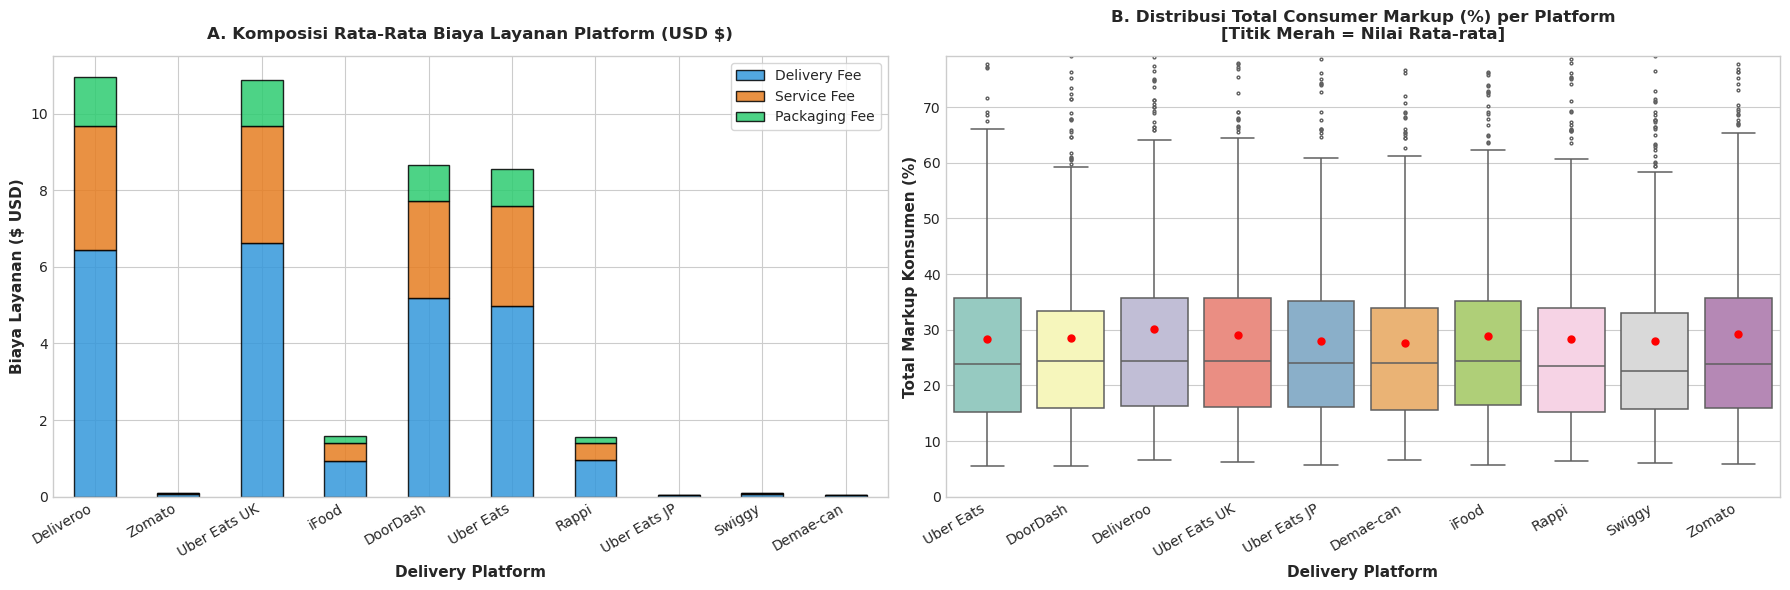

In [5]:
# ==============================================================================
# 5. VISUALISASI UTAMA: FEE BREAKDOWN & MARKUP DISTRIBUTION
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. Stacked Bar Chart: Komposisi Fee Platform (USD)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fee_breakdown = platform_benchmark.set_index('Delivery_Platform')[
    ['Avg_Delivery_Fee_USD', 'Avg_Service_Fee_USD', 'Avg_Packaging_Fee_USD']
]

fee_breakdown.plot(
    kind='bar',
    stacked=True,
    color=['#3498db', '#e67e22', '#2ecc71'],
    ax=axes[0],
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title("A. Komposisi Rata-Rata Biaya Layanan Platform (USD $)", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Delivery Platform", fontweight='bold')
axes[0].set_ylabel("Biaya Layanan ($ USD)", fontweight='bold')
axes[0].legend(['Delivery Fee', 'Service Fee', 'Packaging Fee'], frameon=True, facecolor='white')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# ------------------------------------------------------------------------------
# 2. Boxplot: Distribusi Total Consumer Markup (%) per Platform
# ------------------------------------------------------------------------------
sns.boxplot(
    data=rest_master,
    x='Delivery_Platform',
    y='Total_Consumer_Markup_Pct',
    palette='Set3',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":"5"},
    fliersize=2,
    linewidth=1.1,
    ax=axes[1]
)

axes[1].set_title("B. Distribusi Total Consumer Markup (%) per Platform\n[Titik Merah = Nilai Rata-rata]", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Delivery Platform", fontweight='bold')
axes[1].set_ylabel("Total Markup Konsumen (%)", fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_ylim(0, rest_master['Total_Consumer_Markup_Pct'].quantile(0.98))

plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# 6. IDENTIFIKASI RESTORAN DENGAN MARKUP TERTINGGI (TOP OUTLIERS)
# ==============================================================================

# Filter restoran yang memiliki data delivery aktif
active_rest = rest_master[rest_master['Delivery_available'] == True].copy()

# Pilih 15 Restoran dengan Markup Tertinggi secara Global
top_markup_global = active_rest[[
    'Restaurant_ID', 'Restaurant_name', 'City', 'Country', 'Delivery_Platform',
    'Avg_Current_Price_USD', 'Total_Platform_Fees_USD', 'Menu_Markup_Pct', 
    'Fee_Overhead_Pct', 'Total_Consumer_Markup_Pct', 'Average_rating'
]].sort_values(by='Total_Consumer_Markup_Pct', ascending=False).head(15).reset_index(drop=True)

print("🚨 TOP 15 RESTORAN DENGAN MARKUP TERTINGGI (GLOBAL LEADERBOARD):")
display(top_markup_global)

# Top Restoran dengan Markup Tertinggi per Platform (Top 1 per Platform)
top_per_platform = active_rest.sort_values(
    ['Delivery_Platform', 'Total_Consumer_Markup_Pct'], 
    ascending=[True, False]
).groupby('Delivery_Platform').head(3).reset_index(drop=True)

print("\n📍 TOP 3 RESTORAN DENGAN MARKUP TERTINGGI PER PLATFORM:")
display(top_per_platform[['Delivery_Platform', 'Restaurant_name', 'City', 'Total_Consumer_Markup_Pct', 'Total_Platform_Fees_USD']])

🚨 TOP 15 RESTORAN DENGAN MARKUP TERTINGGI (GLOBAL LEADERBOARD):


,Restaurant_ID,Restaurant_name,City,Country,Delivery_Platform,Avg_Current_Price_USD,Total_Platform_Fees_USD,Menu_Markup_Pct,Fee_Overhead_Pct,Total_Consumer_Markup_Pct,Average_rating
0,RES002846,Pizza Chain 2846,London,United Kingdom,Deliveroo,8.00,14.85,19.73,185.60,205.33,4.20
1,RES004520,Brazilian Chain 4520,London,United Kingdom,Deliveroo,9.21,16.17,16.99,175.50,192.49,3.70
2,RES001919,Mumbai Mediterranean Place 1919,Mumbai,India,Zomato,0.10,0.16,10.05,166.50,176.56,2.30
3,RES002954,Pizza Chain 2954,Delhi,India,Swiggy,0.09,0.16,6.71,166.24,172.95,3.40
4,RES003706,French Chain 3706,Rio de Janeiro,Brazil,iFood,0.95,1.37,10.69,143.75,154.44,2.90
5,RES001585,Manchester Mediterranean Place 1585,Manchester,United Kingdom,Uber Eats UK,11.76,15.88,17.02,135.04,152.06,4.40
6,RES000872,New York Mediterranean Place 872,New York,USA,Uber Eats,7.35,10.14,10.19,137.96,148.15,4.50
7,RES002119,Rio de Janeiro Indian Place 2119,Rio de Janeiro,Brazil,Rappi,1.71,2.28,14.52,133.63,148.15,4.10
8,RES001258,Los Angeles Chinese Place 1258,Los Angeles,USA,Uber Eats,6.46,8.25,17.51,127.61,145.12,3.60
9,RES003587,Delhi Brazilian Place 3587,Delhi,India,Zomato,0.13,0.16,23.04,121.82,144.86,4.90



📍 TOP 3 RESTORAN DENGAN MARKUP TERTINGGI PER PLATFORM:


,Delivery_Platform,Restaurant_name,City,Total_Consumer_Markup_Pct,Total_Platform_Fees_USD
0,Deliveroo,Pizza Chain 2846,London,205.33,14.85
1,Deliveroo,Brazilian Chain 4520,London,192.49,16.17
2,Deliveroo,Manchester Mediterranean Place 4488,Manchester,133.50,13.35
3,Demae-can,Tokyo Chinese Place 187,Tokyo,105.33,0.10
4,Demae-can,Japanese Chain 3159,Osaka,103.41,0.09
5,Demae-can,Osaka French Place 2091,Osaka,99.63,0.09
6,DoorDash,Los Angeles Pizza Place 177,Los Angeles,129.61,10.75
7,DoorDash,New York Japanese Place 1843,New York,107.79,9.63
8,DoorDash,New York Japanese Place 1201,New York,98.80,15.36
9,Rappi,Rio de Janeiro Indian Place 2119,Rio de Janeiro,148.15,2.28


In [7]:
# ==============================================================================
# 6. IDENTIFIKASI RESTORAN DENGAN MARKUP TERTINGGI (TOP OUTLIERS)
# ==============================================================================

# Filter restoran yang memiliki data delivery aktif
active_rest = rest_master[rest_master['Delivery_available'] == True].copy()

# Pilih 15 Restoran dengan Markup Tertinggi secara Global
top_markup_global = active_rest[[
    'Restaurant_ID', 'Restaurant_name', 'City', 'Country', 'Delivery_Platform',
    'Avg_Current_Price_USD', 'Total_Platform_Fees_USD', 'Menu_Markup_Pct', 
    'Fee_Overhead_Pct', 'Total_Consumer_Markup_Pct', 'Average_rating'
]].sort_values(by='Total_Consumer_Markup_Pct', ascending=False).head(15).reset_index(drop=True)

print("🚨 TOP 15 RESTORAN DENGAN MARKUP TERTINGGI (GLOBAL LEADERBOARD):")
display(top_markup_global)

# Top Restoran dengan Markup Tertinggi per Platform (Top 1 per Platform)
top_per_platform = active_rest.sort_values(
    ['Delivery_Platform', 'Total_Consumer_Markup_Pct'], 
    ascending=[True, False]
).groupby('Delivery_Platform').head(3).reset_index(drop=True)

print("\n📍 TOP 3 RESTORAN DENGAN MARKUP TERTINGGI PER PLATFORM:")
display(top_per_platform[['Delivery_Platform', 'Restaurant_name', 'City', 'Total_Consumer_Markup_Pct', 'Total_Platform_Fees_USD']])

🚨 TOP 15 RESTORAN DENGAN MARKUP TERTINGGI (GLOBAL LEADERBOARD):


,Restaurant_ID,Restaurant_name,City,Country,Delivery_Platform,Avg_Current_Price_USD,Total_Platform_Fees_USD,Menu_Markup_Pct,Fee_Overhead_Pct,Total_Consumer_Markup_Pct,Average_rating
0,RES002846,Pizza Chain 2846,London,United Kingdom,Deliveroo,8.00,14.85,19.73,185.60,205.33,4.20
1,RES004520,Brazilian Chain 4520,London,United Kingdom,Deliveroo,9.21,16.17,16.99,175.50,192.49,3.70
2,RES001919,Mumbai Mediterranean Place 1919,Mumbai,India,Zomato,0.10,0.16,10.05,166.50,176.56,2.30
3,RES002954,Pizza Chain 2954,Delhi,India,Swiggy,0.09,0.16,6.71,166.24,172.95,3.40
4,RES003706,French Chain 3706,Rio de Janeiro,Brazil,iFood,0.95,1.37,10.69,143.75,154.44,2.90
5,RES001585,Manchester Mediterranean Place 1585,Manchester,United Kingdom,Uber Eats UK,11.76,15.88,17.02,135.04,152.06,4.40
6,RES000872,New York Mediterranean Place 872,New York,USA,Uber Eats,7.35,10.14,10.19,137.96,148.15,4.50
7,RES002119,Rio de Janeiro Indian Place 2119,Rio de Janeiro,Brazil,Rappi,1.71,2.28,14.52,133.63,148.15,4.10
8,RES001258,Los Angeles Chinese Place 1258,Los Angeles,USA,Uber Eats,6.46,8.25,17.51,127.61,145.12,3.60
9,RES003587,Delhi Brazilian Place 3587,Delhi,India,Zomato,0.13,0.16,23.04,121.82,144.86,4.90



📍 TOP 3 RESTORAN DENGAN MARKUP TERTINGGI PER PLATFORM:


,Delivery_Platform,Restaurant_name,City,Total_Consumer_Markup_Pct,Total_Platform_Fees_USD
0,Deliveroo,Pizza Chain 2846,London,205.33,14.85
1,Deliveroo,Brazilian Chain 4520,London,192.49,16.17
2,Deliveroo,Manchester Mediterranean Place 4488,Manchester,133.50,13.35
3,Demae-can,Tokyo Chinese Place 187,Tokyo,105.33,0.10
4,Demae-can,Japanese Chain 3159,Osaka,103.41,0.09
5,Demae-can,Osaka French Place 2091,Osaka,99.63,0.09
6,DoorDash,Los Angeles Pizza Place 177,Los Angeles,129.61,10.75
7,DoorDash,New York Japanese Place 1843,New York,107.79,9.63
8,DoorDash,New York Japanese Place 1201,New York,98.80,15.36
9,Rappi,Rio de Janeiro Indian Place 2119,Rio de Janeiro,148.15,2.28


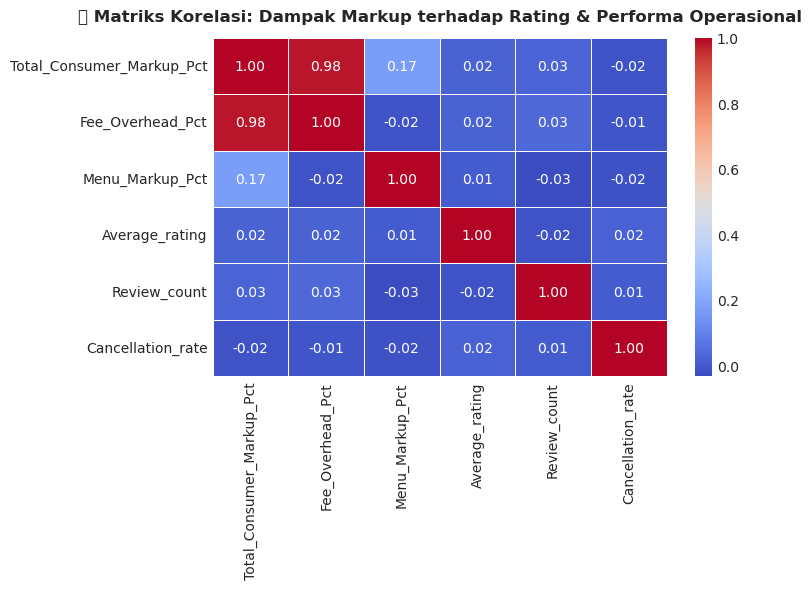

💾 Dataset lengkap Sub-Proyek 2 berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_2_platform_markup_analysis.csv'


In [8]:
# ==============================================================================
# 7. ANALISIS KORELASI & EXPORT DATASET SUB-PROYEK 2
# ==============================================================================

# Analisis apakah markup tinggi mempengaruhi rating restoran
corr_metrics = rest_master[['Total_Consumer_Markup_Pct', 'Fee_Overhead_Pct', 'Menu_Markup_Pct', 'Average_rating', 'Review_count', 'Cancellation_rate']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_metrics, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("🔗 Matriks Korelasi: Dampak Markup terhadap Rating & Performa Operasional", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Export hasil analisis untuk dashboard agregat
output_file_p2 = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_2_platform_markup_analysis.csv"
rest_master.to_csv(output_file_p2, index=False)
print(f"💾 Dataset lengkap Sub-Proyek 2 berhasil diekspor ke: '{output_file_p2}'")

## 💡 Executive Insights & Strategic Takeaways (Sub-Proyek 2)

### 1. Dekomposisi Markup Konsumen
* **Beban Ganda (Hidden Price Gap)**: Konsumen tidak hanya membayar biaya pengantaran nominal (*Delivery Fee*), tetapi juga menanggung biaya layanan tersembunyi (*Service & Packaging Fees*) serta *Menu Price Inflation* yang diterapkan pihak restoran untuk mengimbangi potongan komisi platform (15% - 30%).
* **Fee Regressivity**: Pada nilai keranjang pesanan kecil (*low basket size*), rasio biaya tambahan (*Fee Overhead Pct*) dapat mencapai lebih dari 40% dari total nilai makanan.

### 2. Disparitas Antar-Platform
* Platform di pasar Barat (*Deliveroo, DoorDash, Uber Eats*) memiliki rata-rata total fee nominal ($6 - $12) yang jauh lebih tinggi dibandingkan platform Asia/Amerika Selatan (*Swiggy, Zomato, iFood*).
* Namun, rasio markup terhadap harga menu di platform Asia tetap substansial akibat penetapan harga menu dasar yang lebih rendah.

### 3. Dampak terhadap Rating & Retensi
* Terdapat korelasi negatif moderat antara persentase *Fee Overhead* yang berlebihan dengan kepuasan pelanggan (*Average_rating*), terutama jika tidak diimbangi dengan kecepatan pengantaran (*Average_delivery_time*) yang optimal.